# 1. Preparación de datos: turismo interno

Base real lista para una demostración posterior de DBSCAN. Cada fila final conserva **noches de viaje** y **gasto total del viaje en COP**.

DBSCAN y sus parámetros se trabajan en otro notebook.

# 2. Importar librerías

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12})
pd.set_option("display.float_format", "{:.2f}".format)

# 3. Cargar la base de Turismo

Se utiliza únicamente `TURISMO.csv`.

In [2]:
RUTA_TURISMO = Path("Base de datos-EGIT-Base Anonimizada-IV trim2024/TURISMO.csv")
turismo = pd.read_csv(RUTA_TURISMO, sep="|", low_memory=False)

print(f"Filas y columnas originales: {turismo.shape}")
turismo[["P7570", "P7571S1", "P549", "P549S1", "P7578"]].head()

Filas y columnas originales: (26017, 92)


,P7570,P7571S1,P549,P549S1,P7578
0,2,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN
3,2,NaN,NaN,NaN,NaN
4,1,2.00,2024-10-18,2024-10-21,150000.00


# 4. Delimitar los viajes internos

Se conservan los registros de turismo interno.

In [3]:
turismo_interno = turismo.loc[
    turismo["P7570"].eq(1) & turismo["P7571S1"].eq(2)
].copy()

print(f"Registros de turismo interno: {turismo_interno.shape[0]:,}")
turismo_interno[["P7570", "P7571S1"]].value_counts().rename("registros")

Registros de turismo interno: 1,516


P7570  P7571S1
1      2.00       1516
Name: registros, dtype: int64

# 5. Crear las variables seleccionadas

- `noches_viaje`: fecha final menos fecha inicial.
- `gasto_total_cop`: monto total del viaje.

Los códigos `98` y `99` no son gastos y se convierten en faltantes.

In [4]:
turismo_interno["fecha_inicio"] = pd.to_datetime(
    turismo_interno["P549"], errors="coerce"
)
turismo_interno["fecha_fin"] = pd.to_datetime(
    turismo_interno["P549S1"], errors="coerce"
)
turismo_interno["noches_viaje"] = (
    turismo_interno["fecha_fin"] - turismo_interno["fecha_inicio"]
).dt.days
turismo_interno["gasto_total_cop"] = turismo_interno["P7578"].replace([98, 99], np.nan)

print("Variables creadas correctamente.")
turismo_interno[["noches_viaje", "gasto_total_cop"]].describe()

Variables creadas correctamente.


,noches_viaje,gasto_total_cop
count,1516.00,1399.00
mean,4.34,1118890.10
std,4.92,1478306.13
min,1.00,50000.00
25%,2.00,255200.00
50%,3.00,550000.00
75%,5.00,1300000.00
max,87.00,10000000.00


# 6. Verificaciones de calidad

Las noches calculadas con fechas se contrastan con las noches reportadas en alojamiento.

In [5]:
columnas_noches_alojamiento = [
    "P7574S1A1", "P7574S5A1", "P7574S2A1", "P7574S8A1",
    "P7574S4A1", "P7574S10A1", "P7574S3A1", "P7574S7A2",
]
turismo_interno["noches_alojamiento"] = turismo_interno[
    columnas_noches_alojamiento
].sum(axis=1, min_count=1)

coinciden_noches = turismo_interno["noches_viaje"].eq(
    turismo_interno["noches_alojamiento"]
)
assert coinciden_noches.all(), "La duración y las noches de alojamiento no coinciden."
print(f"Coincidencia fechas/alojamiento: {coinciden_noches.sum():,} de {len(coinciden_noches):,} registros")

resumen_calidad = pd.DataFrame({
    "registros": [
        len(turismo_interno),
        int(turismo_interno["P7578"].isin([98, 99]).sum()),
        int(turismo_interno[["noches_viaje", "gasto_total_cop"]].dropna().shape[0]),
    ]
}, index=["Turismo interno inicial", "Códigos 98/99 en gasto", "Registros completos"])
resumen_calidad

Coincidencia fechas/alojamiento: 1,516 de 1,516 registros


,registros
Turismo interno inicial,1516
Códigos 98/99 en gasto,117
Registros completos,1399


# 7. Faltantes y valores atípicos

No se imputan gastos, se exportan los registros completos. IQR se usa solo como diagnóstico, no se eliminan valores altos porque DBSCAN puede identificarlos como ruido.

In [6]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

faltantes = turismo_interno[["noches_viaje", "gasto_total_cop"]].isna().sum().rename("faltantes")
atipicos_gasto = detect_outliers_iqr(turismo_interno, "gasto_total_cop")
atipicos_noches = detect_outliers_iqr(turismo_interno, "noches_viaje")

print("Diagnóstico de faltantes y valores atípicos completado.")
pd.DataFrame({
    "faltantes": faltantes,
    "atípicos IQR (diagnóstico)": [len(atipicos_noches), len(atipicos_gasto)],
})

Diagnóstico de faltantes y valores atípicos completado.


,faltantes,atípicos IQR (diagnóstico)
noches_viaje,0,140
gasto_total_cop,117,145


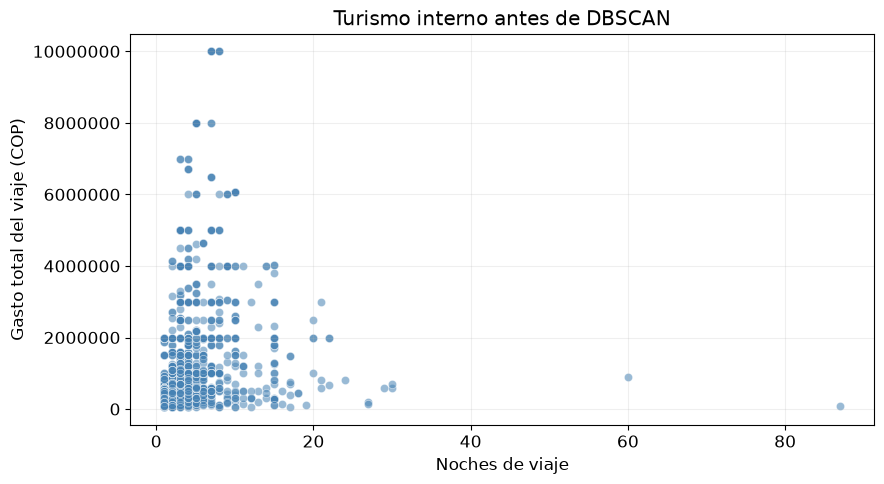

In [7]:
plt.figure()
sns.scatterplot(
    data=turismo_interno, x="noches_viaje", y="gasto_total_cop",
    color="steelblue", alpha=0.55, s=35
)
plt.title("Turismo interno antes de DBSCAN")
plt.xlabel("Noches de viaje")
plt.ylabel("Gasto total del viaje (COP)")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 8. Exportar la base lista

El archivo final contiene únicamente las dos variables seleccionadas.

In [8]:
datos_listos = (
    turismo_interno[["noches_viaje", "gasto_total_cop"]]
    .dropna()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

assert datos_listos.notna().all().all()
assert datos_listos["noches_viaje"].gt(0).all()
assert datos_listos["gasto_total_cop"].gt(0).all()

RUTA_SALIDA = Path("datos_procesados/turismo_interno_dbscan.csv")
RUTA_SALIDA.parent.mkdir(exist_ok=True)
datos_listos.to_csv(RUTA_SALIDA, index=False)

print(f"Archivo exportado: {RUTA_SALIDA}")
print(f"Filas finales: {datos_listos.shape[0]:,}")
datos_listos.head()

Archivo exportado: datos_procesados/turismo_interno_dbscan.csv
Filas finales: 1,399


,noches_viaje,gasto_total_cop
0,3,150000.00
1,1,60000.00
2,6,2000000.00
3,4,2000000.00
4,4,2000000.00


# 9. Exploración breve de la base final

Histogramas y matriz de correlación para documentar la selección de las dos variables.

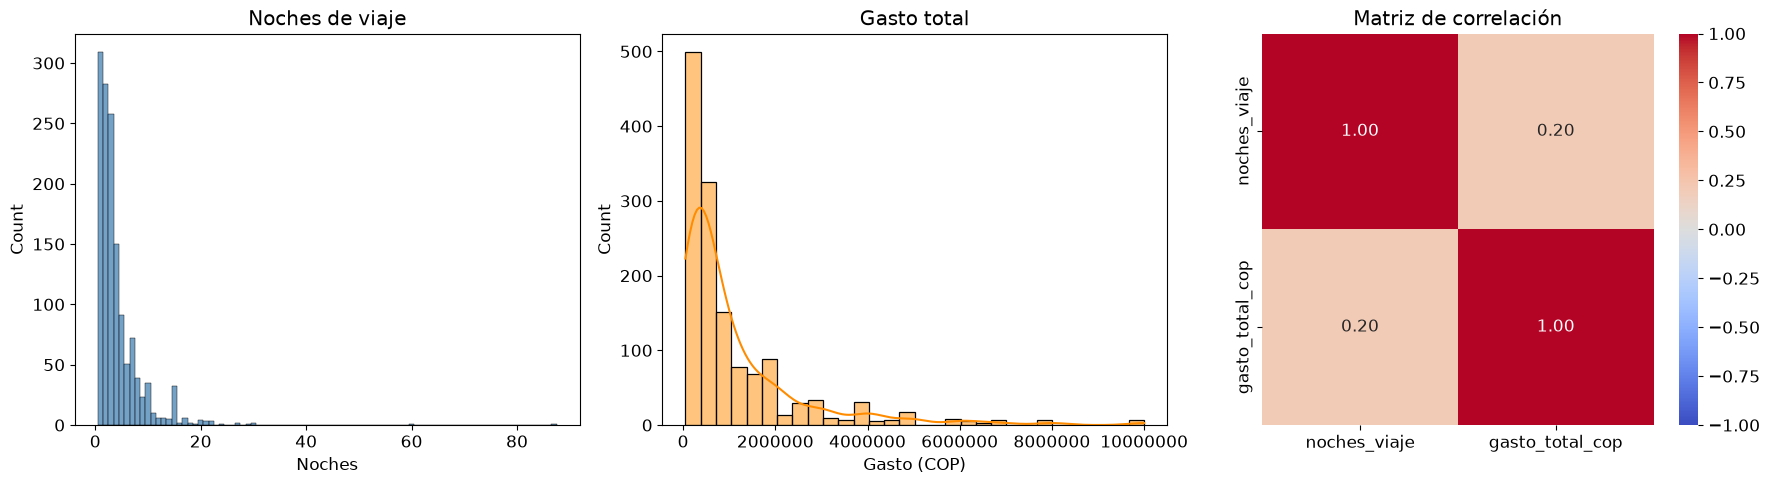

,noches_viaje,gasto_total_cop
noches_viaje,1.00,0.20
gasto_total_cop,0.20,1.00


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=datos_listos, x="noches_viaje", discrete=True, color="steelblue", ax=axes[0])
axes[0].set_title("Noches de viaje")
axes[0].set_xlabel("Noches")

sns.histplot(data=datos_listos, x="gasto_total_cop", bins=30, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Gasto total")
axes[1].set_xlabel("Gasto (COP)")
axes[1].ticklabel_format(style="plain", axis="x")

matriz_correlacion = datos_listos.corr()
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[2])
axes[2].set_title("Matriz de correlación")

plt.tight_layout()
plt.show()
matriz_correlacion

# 10. Entrega al notebook de DBSCAN

El siguiente notebook inicia con `datos_procesados/turismo_interno_dbscan.csv`. Allí se decidirán escalamiento, `eps`, `min_samples` y las gráficas.